# Movie Recommendation System with Explainability - Final Notebook

## 1. Introduction

Movies are one of the most widely consumed forms of entertainment, and our own interest in cinema was the main motivation for this project. As viewers, we often face the same question that streaming platforms try to answer every day: **what should I watch next?** With thousands of titles available, manual browsing quickly becomes inefficient. A recommendation system can reduce this search effort by learning user preferences and ranking movies that are likely to be relevant for each person.

The goal of this project is to build a movie recommendation system that supports users with existing rating history and users with little or no history. For users with rating history, the system can learn from previous interactions and recommend movies similar to what they liked before. For users with weak history, the system must rely more on general popularity and metadata such as genres.

This problem matters because recommender systems are now central to how people consume media. Streaming platforms have become increasingly popular and have largely replaced traditional television for many viewers. Platforms such as Netflix, Disney+, HBO Max, Amazon Prime Video, and others depend on recommendation systems to keep users engaged and make large catalogs usable.

The main challenges are cold start, data sparsity, popularity bias, changing user preferences, and the need to evaluate recommendations as ranked lists rather than only as exact rating predictions. Explainability is also important: a recommendation is more useful when the user can understand why it was suggested.

In [1]:
from pathlib import Path
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\rafal\OneDrive\Dokumente\GitHub\Movie-Recommendation-System-with-Explainability


## 2. Data Loading & Validation

The data comes from the GroupLens MovieLens collection: https://grouplens.org/datasets/movielens/

We use the MovieLens `latest-small` dataset. It contains approximately 100,000 ratings and 3,600 tag applications applied to around 9,000 movies by around 600 users. The dataset was last updated in September 2018.

The raw files are:

- `ratings.csv`: user-movie ratings and timestamps
- `movies.csv`: movie titles and genres
- `tags.csv`: user-generated tags
- `links.csv`: external IMDb/TMDB identifiers

This notebook follows the same first pipeline step as `main.py --mode data`: it calls `prep_master_data()` from `src/data_pipeline.py`, which creates the processed master parquet file used by the rest of the project.

In [2]:
raw_required_paths = {
    "ratings": PROJECT_ROOT / "data" / "raw" / "ratings.csv",
    "movies": PROJECT_ROOT / "data" / "raw" / "movies.csv",
    "tags": PROJECT_ROOT / "data" / "raw" / "tags.csv",
    "links": PROJECT_ROOT / "data" / "raw" / "links.csv",
}

raw_file_check = pd.DataFrame(
    [
        {"artifact": name, "path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()}
        for name, path in raw_required_paths.items()
    ]
)
display(raw_file_check)

missing_raw = raw_file_check.loc[~raw_file_check["exists"], "artifact"].tolist()
if missing_raw:
    raise FileNotFoundError(f"Missing raw data files: {missing_raw}")

,artifact,path,exists
0,ratings,data\raw\ratings.csv,True
1,movies,data\raw\movies.csv,True
2,tags,data\raw\tags.csv,True
3,links,data\raw\links.csv,True


In [3]:
from src.data_pipeline import prep_master_data

# Run the same data-preparation step used by main.py --mode data.
prep_master_data()

processed_path = PROJECT_ROOT / "data" / "processed" / "master_data_small.parquet"
if not processed_path.exists():
    raise FileNotFoundError(f"Processed master dataset was not created: {processed_path}")

ratings = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "ratings.csv")
movies = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "movies.csv")
tags = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "tags.csv")
links = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "links.csv")

ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
master_df = pd.read_parquet(processed_path)
raw_tables = {"ratings": ratings, "movies": movies, "tags": tags, "links": links}

standard_cols = {"userId", "movieId", "rating", "timestamp", "datetime", "title"}
genre_cols = [col for col in master_df.columns if col not in standard_cols]

data_characteristics = pd.DataFrame(
    {
        "metric": [
            "raw ratings",
            "users",
            "movies in ratings",
            "movie metadata rows",
            "tag applications",
            "processed master shape",
            "genre feature columns",
            "rating min",
            "rating max",
            "rating mean",
            "earliest rating",
            "latest rating",
        ],
        "value": [
            len(ratings),
            ratings["userId"].nunique(),
            ratings["movieId"].nunique(),
            len(movies),
            len(tags),
            master_df.shape,
            len(genre_cols),
            ratings["rating"].min(),
            ratings["rating"].max(),
            round(ratings["rating"].mean(), 3),
            ratings["datetime"].min(),
            ratings["datetime"].max(),
        ],
    }
)

validation_checks = pd.DataFrame(
    [
        {"check": "ratings in expected range [0.5, 5.0]", "passed": ratings["rating"].between(0.5, 5.0).all()},
        {"check": "no duplicate user-movie rating pairs", "passed": ratings.duplicated(["userId", "movieId"]).sum() == 0},
        {"check": "all rated movieIds exist in movies metadata", "passed": set(ratings["movieId"]).issubset(set(movies["movieId"]))},
        {"check": "processed master row count equals raw ratings", "passed": len(master_df) == len(ratings)},
        {"check": "processed master sorted by user and datetime", "passed": master_df.equals(master_df.sort_values(["userId", "datetime"]))},
        {"check": "genre columns are binary", "passed": master_df[genre_cols].isin([0, 1]).all().all()},
        {"check": "critical processed columns complete", "passed": master_df[["userId", "movieId", "rating", "datetime", "title"]].isna().sum().sum() == 0},
    ]
)

missing_values = pd.DataFrame(
    [{"table": name, "missing_values": int(df.isna().sum().sum())} for name, df in raw_tables.items()]
)

display(data_characteristics)
display(validation_checks)
display(missing_values)

✅ Saved dataset to C:\Users\rafal\OneDrive\Dokumente\GitHub\Movie-Recommendation-System-with-Explainability\data\processed\master_data_small.parquet
Shape: (100836, 26)
Extracted 20 unique genres.


,metric,value
0,raw ratings,100836
1,users,610
2,movies in ratings,9724
3,movie metadata rows,9742
4,tag applications,3683
5,processed master shape,"(100836, 26)"
6,genre feature columns,20
7,rating min,0.5
8,rating max,5.0
9,rating mean,3.502


,check,passed
0,"ratings in expected range [0.5, 5.0]",True
1,no duplicate user-movie rating pairs,True
2,all rated movieIds exist in movies metadata,True
3,processed master row count equals raw ratings,True
4,processed master sorted by user and datetime,True
5,genre columns are binary,True
6,critical processed columns complete,True


,table,missing_values
0,ratings,0
1,movies,0
2,tags,0
3,links,8


## 3. Exploratory Data Analysis (EDA)

The full EDA is available in `notebooks/eda.ipynb`. This final notebook includes only the most essential EDA outputs needed to justify the modeling decisions: rating distribution, interaction sparsity, user/movie activity imbalance, and genre distribution.

,metric,value
0,matrix sparsity,0.983
1,median ratings per user,70.5
2,max ratings by one user,2698
3,median ratings per movie,3.0
4,max ratings for one movie,329
5,most common genre,Drama


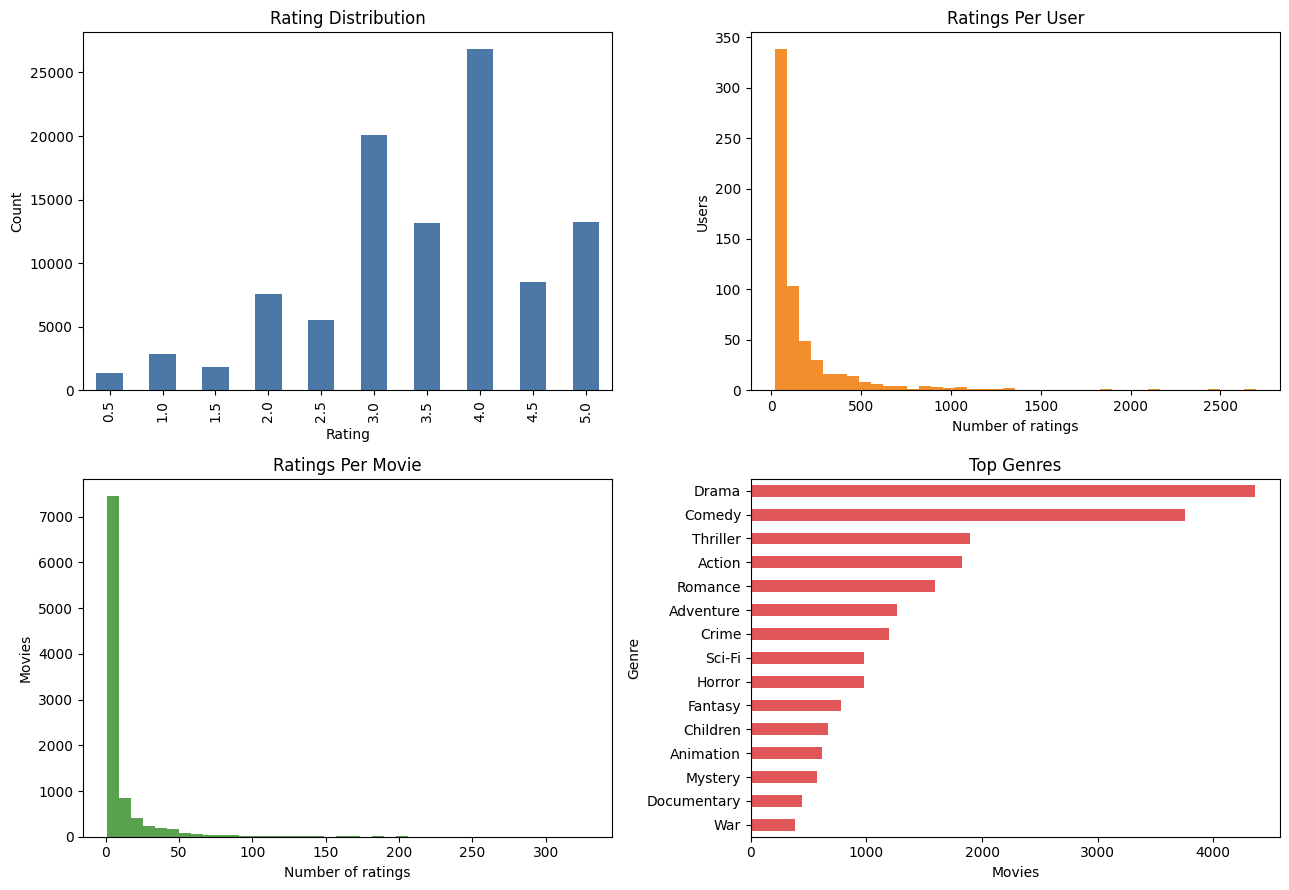

In [4]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()
possible_interactions = ratings["userId"].nunique() * ratings["movieId"].nunique()
sparsity = 1 - len(ratings) / possible_interactions

movie_genres = movies.copy()
movie_genres["genre_list"] = movie_genres["genres"].str.split("|")
genre_counts = (
    movie_genres.explode("genre_list")
    .query("genre_list != '(no genres listed)'")
    ["genre_list"]
    .value_counts()
)

eda_summary = pd.DataFrame(
    {
        "metric": [
            "matrix sparsity",
            "median ratings per user",
            "max ratings by one user",
            "median ratings per movie",
            "max ratings for one movie",
            "most common genre",
        ],
        "value": [
            round(sparsity, 4),
            ratings_per_user.median(),
            ratings_per_user.max(),
            ratings_per_movie.median(),
            ratings_per_movie.max(),
            genre_counts.index[0],
        ],
    }
)

display(eda_summary)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Rating Distribution")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Count")

ratings_per_user.plot(kind="hist", bins=40, ax=axes[0, 1], color="#F28E2B")
axes[0, 1].set_title("Ratings Per User")
axes[0, 1].set_xlabel("Number of ratings")
axes[0, 1].set_ylabel("Users")

ratings_per_movie.plot(kind="hist", bins=40, ax=axes[1, 0], color="#59A14F")
axes[1, 0].set_title("Ratings Per Movie")
axes[1, 0].set_xlabel("Number of ratings")
axes[1, 0].set_ylabel("Movies")

genre_counts.head(15).sort_values().plot(kind="barh", ax=axes[1, 1], color="#E15759")
axes[1, 1].set_title("Top Genres")
axes[1, 1].set_xlabel("Movies")
axes[1, 1].set_ylabel("Genre")

plt.tight_layout()

### 3.1 EDA Conclusions And Modeling Implications

The EDA is not only descriptive; it directly motivates the modeling strategy. The most important conclusion is that the MovieLens interaction matrix is highly sparse, so one model type is unlikely to solve every recommendation case. This is why the final system combines collaborative filtering, popularity, and genre-based content signals.

The plots above imply the following modeling decisions:

In [5]:
eda_implications = pd.DataFrame(
    [
        {
            "EDA finding": f"User-movie matrix sparsity is {sparsity:.1%}",
            "Model implication": "Collaborative filtering must handle many missing interactions; top-K evaluation is more appropriate than dense rating prediction.",
        },
        {
            "EDA finding": "Ratings are not uniformly distributed",
            "Model implication": "Positive feedback is defined with a threshold, rating >= 4.0, so the task becomes ranking relevant movies.",
        },
        {
            "EDA finding": f"Median ratings per movie is only {ratings_per_movie.median():.1f}",
            "Model implication": "Many movies have weak collaborative evidence; popularity smoothing and genre features help stabilize recommendations.",
        },
        {
            "EDA finding": f"User activity is uneven; median ratings per user is {ratings_per_user.median():.1f}",
            "Model implication": "The system needs to support both active users and users with limited history; hybrid ranking is safer than pure KNN.",
        },
        {
            "EDA finding": f"Most common genre is {genre_counts.index[0]}",
            "Model implication": "Genre features are useful but can introduce genre imbalance; diversity reranking helps avoid overly narrow lists.",
        },
        {
            "EDA finding": "Some movies receive far more ratings than others",
            "Model implication": "Popularity is a strong baseline, but Bayesian smoothing is needed to avoid overtrusting movies with very few ratings.",
        },
    ]
)
eda_implications

,EDA finding,Model implication
0,User-movie matrix sparsity is 98.3%,Collaborative filtering must handle many missi...
1,Ratings are not uniformly distributed,"Positive feedback is defined with a threshold,..."
2,Median ratings per movie is only 3.0,Many movies have weak collaborative evidence; ...
3,User activity is uneven; median ratings per us...,The system needs to support both active users ...
4,Most common genre is Drama,Genre features are useful but can introduce ge...
5,Some movies receive far more ratings than others,"Popularity is a strong baseline, but Bayesian ..."


In summary, the EDA supports the final model choice. The hybrid ranker is appropriate because it combines:

- **collaborative evidence** from item-item KNN when user history is available
- **popularity evidence** for reliable generally liked movies and sparse cases
- **genre evidence** for content alignment and cold-start-like situations
- **diversity reranking** to reduce repetitive recommendation lists

This is why the final application does not rely only on NeuMF or only on item-item KNN, even though both are useful components or benchmarks.

## 4. Feature Engineering

This section performs the same core transformations used by the project pipeline:

- convert timestamps to datetime
- multi-hot encode genres
- merge ratings with movie metadata
- create a temporal per-user split
- define positive interactions as `rating >= 4.0`
- prepare negative-sampling metadata for ranking models
- confirm that saved model artifacts are available


In [6]:
# Continue from the processed master dataset created by prep_master_data().
master_df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "master_data_small.parquet")
standard_cols = {"userId", "movieId", "rating", "timestamp", "datetime", "title"}
genre_cols = [col for col in master_df.columns if col not in standard_cols]

split_df = master_df.copy().sort_values(["userId", "datetime"])
split_df["rank"] = split_df.groupby("userId").cumcount()
split_df["count"] = split_df.groupby("userId")["userId"].transform("count")
train_df = split_df[split_df["rank"] < split_df["count"] * 0.8].copy()
test_df = split_df[split_df["rank"] >= split_df["count"] * 0.8].copy()

positive_threshold = 4.0
train_positive = train_df[train_df["rating"] >= positive_threshold]
test_positive = test_df[test_df["rating"] >= positive_threshold]

example_user = int(train_positive["userId"].iloc[0])
negative_pool_size = len(set(master_df["movieId"].unique()) - set(train_df.loc[train_df["userId"] == example_user, "movieId"]))

feature_summary = pd.DataFrame(
    {
        "object": [
            "pipeline-created master dataset",
            "genre columns from prep_master_data",
            "train interactions",
            "test interactions",
            "train positive interactions",
            "test positive interactions",
            "example user's negative candidate pool",
        ],
        "value": [
            str((PROJECT_ROOT / "data" / "processed" / "master_data_small.parquet").relative_to(PROJECT_ROOT)),
            len(genre_cols),
            len(train_df),
            len(test_df),
            len(train_positive),
            len(test_positive),
            negative_pool_size,
        ],
    }
)
feature_summary

,object,value
0,pipeline-created master dataset,data\processed\master_data_small.parquet
1,genre columns from prep_master_data,20
2,train interactions,80896
3,test interactions,19940
4,train positive interactions,39348
5,test positive interactions,9232
6,example user's negative candidate pool,9538


In [7]:
model_artifacts = {
    "ranking NeuMF weights": PROJECT_ROOT / "models" / "neumf_ranking_model.pth",
    "ranking user encoder": PROJECT_ROOT / "models" / "ranking_user_encoder.pkl",
    "ranking item encoder": PROJECT_ROOT / "models" / "ranking_item_encoder.pkl",
    "ranking genre columns": PROJECT_ROOT / "models" / "ranking_genre_cols.pkl",
    "top-K evaluation summary": PROJECT_ROOT / "reports" / "topk_evaluation_summary.csv",
    "ranking training history": PROJECT_ROOT / "reports" / "neumf_ranking_training_history.csv",
}

artifact_status = pd.DataFrame(
    [
        {"artifact": name, "path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()}
        for name, path in model_artifacts.items()
    ]
)
display(artifact_status)

if not artifact_status["exists"].all():
    raise FileNotFoundError("One or more final model artifacts are missing.")

,artifact,path,exists
0,ranking NeuMF weights,models\neumf_ranking_model.pth,True
1,ranking user encoder,models\ranking_user_encoder.pkl,True
2,ranking item encoder,models\ranking_item_encoder.pkl,True
3,ranking genre columns,models\ranking_genre_cols.pkl,True
4,top-K evaluation summary,reports\topk_evaluation_summary.csv,True
5,ranking training history,reports\neumf_ranking_training_history.csv,True


## 5. Modeling

The project compares multiple techniques, from simple baselines to advanced hybrid models. Heavy training is **not rerun** inside this final notebook; instead, this notebook loads the saved training history and final model artifacts produced by the project pipeline.

The equivalent training command for the final ranking NeuMF is:

```powershell
python main.py --mode train_rank_neumf --ranking-epochs 5 --negative-samples 4
```

The final application model is the `HybridRanker`, which is loaded and used directly below.

| Model | Technique | Role |
| :--- | :--- | :--- |
| `random` | random ranking | sanity-check baseline |
| `popularity_bayes` | Bayesian-smoothed popularity | simple strong baseline |
| `genre_personalized_popularity` | popularity + user genre profile | content-aware baseline |
| `item_item_knn` | item-item collaborative filtering | explainable collaborative model |
| `neumf_rating_model` | rating-prediction NeuMF | original neural model |
| `neumf_ranking_model` | ranking NeuMF with sampled negatives | strong neural benchmark |
| `hybrid_ranker` | weighted item KNN + popularity + genre | final application model |

,epoch,loss,precision@10,recall@10,hit_rate@10,ndcg@10,is_best
0,1,0.5845,0.148,0.1256,0.63,0.1755,True
1,2,0.4605,0.247,0.2502,0.80,0.3319,True
2,3,0.4189,0.341,0.3660,0.88,0.4566,True
3,4,0.3772,0.395,0.4405,0.89,0.5371,True
4,5,0.3376,0.423,0.5182,0.94,0.5914,True
5,6,0.3111,0.428,0.5096,0.93,0.5935,True
6,7,0.2957,0.433,0.5208,0.93,0.6032,True
7,8,0.2855,0.429,0.5170,0.93,0.6063,True
8,9,0.2775,0.428,0.5143,0.93,0.6006,False
9,10,0.2719,0.428,0.5047,0.91,0.6052,False


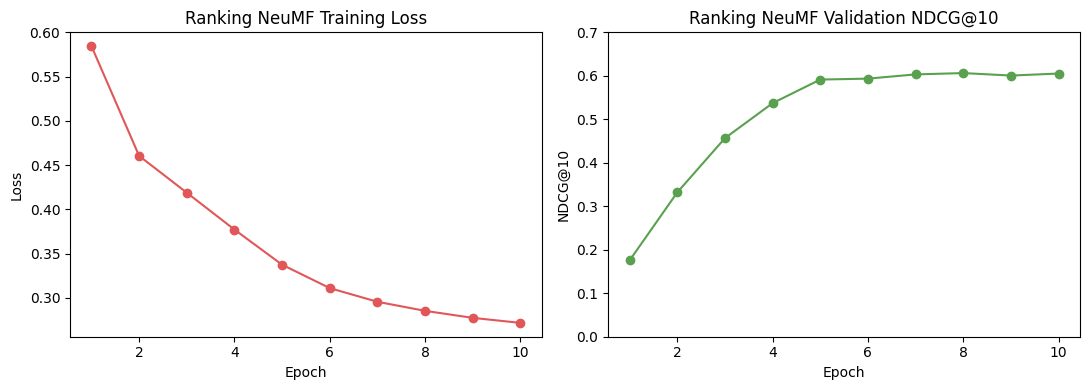

In [9]:
history = pd.read_csv(PROJECT_ROOT / "reports" / "neumf_ranking_training_history.csv")
display(history.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history.plot(x="epoch", y="loss", marker="o", ax=axes[0], color="#E15759", legend=False)
axes[0].set_title("Ranking NeuMF Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

history.plot(x="epoch", y="ndcg@10", marker="o", ax=axes[1], color="#59A14F", legend=False)
axes[1].set_title("Ranking NeuMF Validation NDCG@10")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("NDCG@10")
axes[1].set_ylim(0, max(0.7, history["ndcg@10"].max() + 0.05))
plt.tight_layout()

In [37]:
from src.hybrid_ranker import HybridRanker, DEFAULT_HYBRID_WEIGHTS

ranker = HybridRanker(diversity_weight=0.05)
demo_user = ranker.available_user_ids()[0]
liked_movies = ranker.user_liked_movies(demo_user, limit=5)
recommendations = ranker.recommend_for_user(demo_user, top_n=10, diversity_weight=0.05)

hybrid_weights = pd.DataFrame(
    [
        {"component": "item_item_knn", "weight": DEFAULT_HYBRID_WEIGHTS["item_knn"]},
        {"component": "popularity", "weight": DEFAULT_HYBRID_WEIGHTS["popularity"]},
        {"component": "genre", "weight": DEFAULT_HYBRID_WEIGHTS["genre"]},
    ]
)

In [36]:
hybrid_weights

,component,weight,meaning
0,item_item_knn,0.50,similarity to movies the user liked
1,popularity,0.25,Bayesian-smoothed global reception
2,genre,0.25,match with user's genre profile


In [38]:
liked_movies

,movieId,title,rating
0,2959,Fight Club (1999),5.0
1,2329,American History X (1998),5.0
2,954,Mr. Smith Goes to Washington (1939),5.0
3,2387,Very Bad Things (1998),5.0
4,1804,"Newton Boys, The (1998)",5.0


In [39]:
display(recommendations[["title", "genres", "relevance_score", "item_knn_score", "popularity_score", "genre_score", "explanation_summary"]].head(10))

,title,genres,relevance_score,item_knn_score,popularity_score,genre_score,explanation_summary
0,For Your Eyes Only (1981),Action | Adventure | Thriller,0.8430,1.0000,0.5885,0.7836,Main signal: similarity to movies the user liked.
1,"Lord of the Rings: The Return of the King, The...",Action | Adventure | Drama | Fantasy,0.7839,0.6982,0.8680,0.8713,Main signal: similarity to movies the user liked.
2,"Spy Who Loved Me, The (1977)",Action | Adventure | Thriller,0.7871,0.8839,0.5968,0.7836,Main signal: similarity to movies the user liked.
3,Licence to Kill (1989),Action | Adventure | Thriller,0.7794,0.8944,0.5449,0.7836,Main signal: similarity to movies the user liked.
4,Austin Powers: The Spy Who Shagged Me (1999),Action | Adventure | Comedy,0.7617,0.8291,0.4970,0.8917,Main signal: similarity to movies the user liked.
5,X2: X-Men United (2003),Action | Adventure | Sci-Fi | Thriller,0.7557,0.7951,0.6641,0.7685,Main signal: similarity to movies the user liked.
6,Dragonslayer (1981),Action | Adventure | Fantasy,0.7523,0.7638,0.6872,0.7946,Main signal: similarity to movies the user liked.
7,Diamonds Are Forever (1971),Action | Adventure | Thriller,0.7555,0.8165,0.6052,0.7836,Main signal: similarity to movies the user liked.
8,Ben-Hur (1959),Action | Adventure | Drama,0.7390,0.6852,0.7408,0.8450,Main signal: similarity to movies the user liked.
9,Back to the Future (1985),Adventure | Comedy | Sci-Fi,0.7280,0.6984,0.8242,0.6911,Main signal: similarity to movies the user liked.


## 6. Evaluation

The final benchmark is top-K ranking evaluation, not only rating prediction. The project evaluates whether relevant held-out movies appear in the top recommendation list.

The equivalent command is:

```powershell
python main.py --mode eval_topk --run-label benchmark
```


| Metric | Meaning |
| :--- | :--- |
| `Precision@K` | share of recommended movies that are relevant |
| `Recall@K` | share of relevant held-out movies recovered |
| `HitRate@K` | whether at least one relevant movie appears in the top K |
| `NDCG@K` | ranking quality; rewards relevant movies near the top |

In [41]:
summary = pd.read_csv(PROJECT_ROOT / "reports" / "topk_evaluation_summary.csv")
metric_cols = [col for col in summary.columns if col != "recommender"]
summary[metric_cols] = summary[metric_cols].round(4)
benchmark_table = summary.sort_values("ndcg@10", ascending=False).reset_index(drop=True)
display(benchmark_table)

,recommender,precision@5,recall@5,hit_rate@5,ndcg@5,precision@10,recall@10,hit_rate@10,ndcg@10
0,hybrid_ranker,0.478,0.3386,0.90,0.5538,0.397,0.5041,0.95,0.5843
1,neumf_ranking_model,0.486,0.3015,0.87,0.5370,0.415,0.4846,0.91,0.5686
2,item_item_knn,0.448,0.3171,0.84,0.5016,0.382,0.4832,0.94,0.5409
3,popularity_bayes,0.398,0.2478,0.78,0.4575,0.330,0.3813,0.85,0.4731
4,genre_personalized_popularity,0.414,0.2833,0.86,0.4834,0.312,0.3726,0.88,0.4689
5,neumf_rating_model,0.176,0.0921,0.54,0.1668,0.176,0.1821,0.71,0.1977
6,random,0.108,0.0592,0.40,0.1210,0.104,0.1196,0.62,0.1359


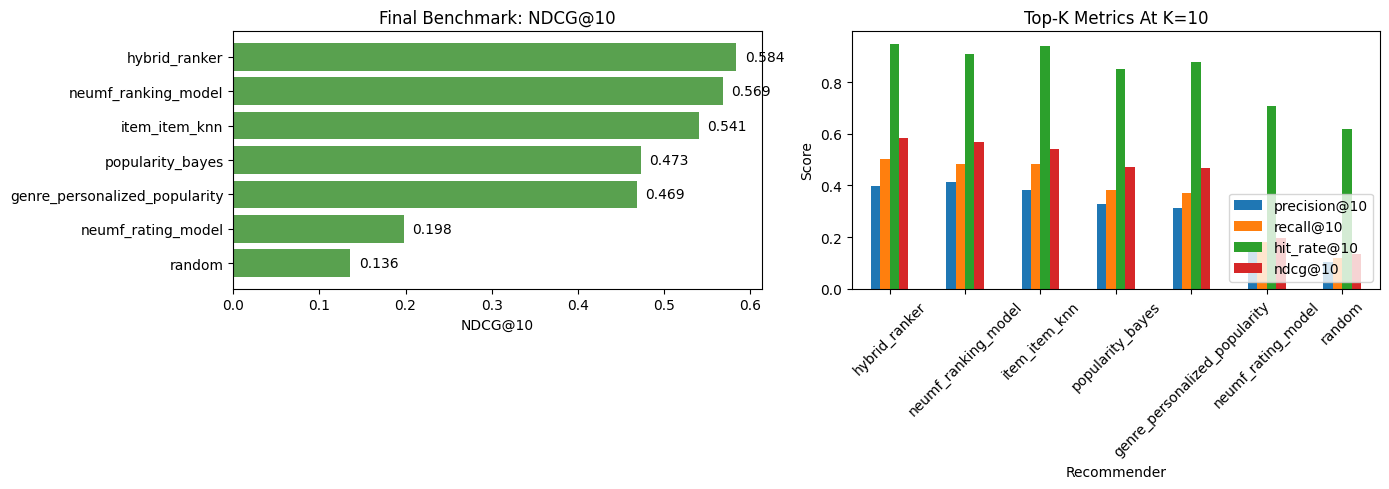

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ranked_summary = summary.sort_values("ndcg@10", ascending=True)
axes[0].barh(ranked_summary["recommender"], ranked_summary["ndcg@10"], color="#59A14F")
axes[0].set_title("Final Benchmark: NDCG@10")
axes[0].set_xlabel("NDCG@10")
for index, value in enumerate(ranked_summary["ndcg@10"]):
    axes[0].text(value + 0.01, index, f"{value:.3f}", va="center")

summary.set_index("recommender")[["precision@10", "recall@10", "hit_rate@10", "ndcg@10"]].loc[benchmark_table["recommender"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Top-K Metrics At K=10")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Recommender")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(loc="lower right")
plt.tight_layout()

In [43]:
best_row = benchmark_table.iloc[0]
neural_row = summary.loc[summary["recommender"] == "neumf_ranking_model"].iloc[0]
random_row = summary.loc[summary["recommender"] == "random"].iloc[0]

print(f"Best final model: {best_row['recommender']} with NDCG@10={best_row['ndcg@10']:.4f}")
print(f"Best neural model: neumf_ranking_model with NDCG@10={neural_row['ndcg@10']:.4f}")
print(f"Improvement over random: {best_row['ndcg@10'] / random_row['ndcg@10']:.1f}x NDCG@10")

k = 10
confusion_style = summary[["recommender", "precision@10", "recall@10", "hit_rate@10", "ndcg@10"]].copy()
confusion_style["recommended_relevant_per_user"] = confusion_style["precision@10"] * k
confusion_style["recommended_not_relevant_per_user"] = k - confusion_style["recommended_relevant_per_user"]
confusion_style["estimated_relevant_items_per_user"] = np.where(
    confusion_style["recall@10"] > 0,
    confusion_style["recommended_relevant_per_user"] / confusion_style["recall@10"],
    np.nan,
)
confusion_style["estimated_missed_relevant_per_user"] = (
    confusion_style["estimated_relevant_items_per_user"] - confusion_style["recommended_relevant_per_user"]
)
display(confusion_style.sort_values("ndcg@10", ascending=False).round(3))

Best final model: hybrid_ranker with NDCG@10=0.5843
Best neural model: neumf_ranking_model with NDCG@10=0.5686
Improvement over random: 4.3x NDCG@10


,recommender,precision@10,recall@10,hit_rate@10,ndcg@10,recommended_relevant_per_user,recommended_not_relevant_per_user,estimated_relevant_items_per_user,estimated_missed_relevant_per_user
1,hybrid_ranker,0.397,0.504,0.95,0.584,3.97,6.03,7.875,3.905
3,neumf_ranking_model,0.415,0.485,0.91,0.569,4.15,5.85,8.564,4.414
2,item_item_knn,0.382,0.483,0.94,0.541,3.82,6.18,7.906,4.086
5,popularity_bayes,0.330,0.381,0.85,0.473,3.30,6.70,8.655,5.355
0,genre_personalized_popularity,0.312,0.373,0.88,0.469,3.12,6.88,8.374,5.254
4,neumf_rating_model,0.176,0.182,0.71,0.198,1.76,8.24,9.665,7.905
6,random,0.104,0.120,0.62,0.136,1.04,8.96,8.696,7.656


## 7. Interpretability

The full interpretability analysis is available in `notebooks/final_interpretability_analysis.ipynb`. This final notebook includes only the essential demo-level explanation.

The final model is explainable at several levels:

- item-item KNN evidence: similar movies the user liked
- hybrid component contributions: item similarity, popularity, and genre affinity
- SHAP-style top-level attributions over the three hybrid components
- deeper feature-level explanations in the dedicated interpretability notebook


Explained recommendation: For Your Eyes Only (1981)
Main signal: similarity to movies the user liked.

Similar liked movies used as collaborative evidence:


,movieId,supporting_liked_movie,item_similarity
0,2993,Thunderball (1965),0.755929
1,2948,From Russia with Love (1963),0.623610
2,2949,Dr. No (1962),0.516398



Hybrid component contributions:


,component,weighted_contribution
0,item_knn,0.500000
1,popularity,0.147125
2,genre,0.195900



SHAP-style top-level attributions:


,shap_value
item_knn_shap,0.5
popularity_shap,0.147125
genre_shap,0.1959


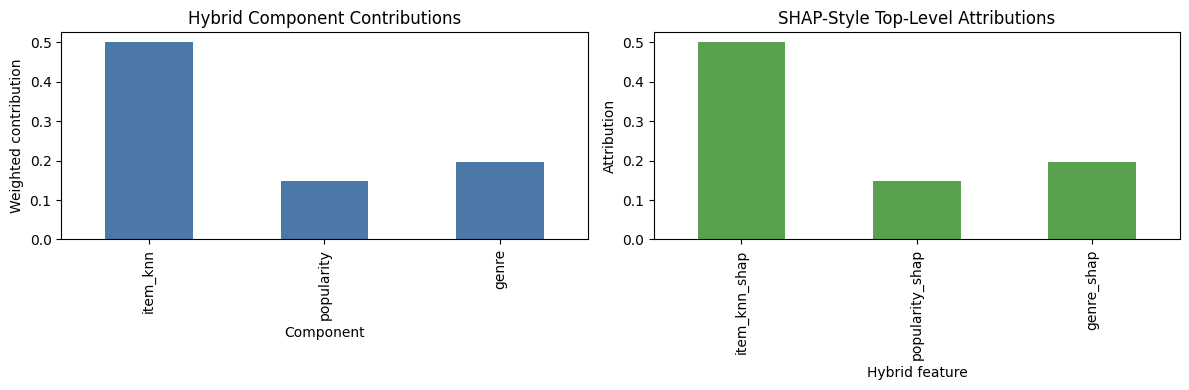

In [15]:
first = recommendations.iloc[0]
print(f"Explained recommendation: {first['title']}")
print(first["explanation_summary"])

print()
print("Similar liked movies used as collaborative evidence:")
evidence_df = pd.DataFrame(first["explanations"])
if evidence_df.empty:
    print("No direct KNN evidence available.")
else:
    display(evidence_df.rename(columns={"title": "supporting_liked_movie", "similarity": "item_similarity"}))

contribution = first["component_contributions"]
contribution_df = pd.DataFrame(
    [
        {"component": component, "weighted_contribution": value}
        for component, value in contribution.get("contributions", {}).items()
    ]
)
print()
print("Hybrid component contributions:")
display(contribution_df)

shap_cols = ["item_knn_shap", "popularity_shap", "genre_shap"]
print()
print("SHAP-style top-level attributions:")
display(first[shap_cols].to_frame("shap_value"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
contribution_df.plot(kind="bar", x="component", y="weighted_contribution", ax=axes[0], legend=False, color="#4C78A8")
axes[0].set_title("Hybrid Component Contributions")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Weighted contribution")

first[shap_cols].astype(float).plot(kind="bar", ax=axes[1], color="#59A14F")
axes[1].set_title("SHAP-Style Top-Level Attributions")
axes[1].set_xlabel("Hybrid feature")
axes[1].set_ylabel("Attribution")
plt.tight_layout()

## 8. Conclusions

This project developed an explainable movie recommendation system using the MovieLens `latest-small` dataset. The most important lesson is that a recommender should be optimized and evaluated as a ranking system, not only as a rating predictor.

Key findings:

- The dataset is highly sparse, which motivates hybrid modeling.
- Popularity is a strong baseline, but it is not enough on its own.
- Item-item KNN provides strong collaborative recommendations and clear explanations.
- Ranking NeuMF is the strongest neural model after changing the objective from rating prediction to ranking.
- The hybrid ranker is the best final application model because it achieves the strongest final sampled `NDCG@10` and provides clear explanations.

Limitations:

- Main evaluation uses sampled negatives rather than full-catalog ranking.
- Cold-start users and new movies are only partially solved.
- Metadata is mostly limited to genres and tags.
- Neural explanations are less direct than hybrid explanations.

Future work:

- evaluate on larger full-catalog samples
- add onboarding for cold-start users
- enrich movie metadata with plots, cast, directors, and posters
- add ranking NeuMF as an optional app mode
- improve diversity beyond genre-based reranking
- evaluate explanation quality more formally

The final project includes a working pipeline, saved model artifacts, benchmark reports, a Streamlit demo, and dedicated interpretability analysis.